# Phase 4 — Machine Learning Models
### Personal Spending Intelligence System

**What this notebook does:**
Trains three regression models on the features from Phase 3 to predict monthly savings rate.
Compares them using MAE and R², then explains which features drive predictions the most.

**What you will learn:**
- Train/test split and why it matters
- How to train Linear Regression, Ridge Regression, and Random Forest
- MAE and R² — the two evaluation metrics that matter most for regression
- Feature importance — which spending patterns actually predict savings rate
- Cross-validation — a more honest way to evaluate a small dataset


## Step 1 — Imports

`sklearn` (scikit-learn) is Python's most important machine learning library.
It gives us ready-made implementations of every model we need.
All sklearn models share the same interface: `.fit()` to train, `.predict()` to predict.
This consistency is called the **estimator API** — once you learn one model, you know them all.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn — the machine learning library
from sklearn.linear_model import LinearRegression, Ridge
# LinearRegression: fits a straight line through data
# Ridge: same but with regularisation (prevents overfitting)

from sklearn.ensemble import RandomForestRegressor
# RandomForestRegressor: builds many decision trees and averages them

from sklearn.model_selection import train_test_split, cross_val_score
# train_test_split: splits data into train and test sets
# cross_val_score: evaluates model on multiple folds (more honest for small datasets)

from sklearn.metrics import mean_absolute_error, r2_score
# mean_absolute_error: average gap between predicted and actual values
# r2_score: how much of the variance the model explains (0 to 1)

from sklearn.preprocessing import StandardScaler
# StandardScaler: rescales features so they all have mean=0, std=1
# Required for linear models — without it, a feature worth Rs.18000 drowns out one worth Rs.200

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("Libraries loaded successfully")


Libraries loaded successfully


## Step 2 — Load features from Phase 3

We load the X (features) and y (target) files saved in Phase 3.
Then we do a quick check to make sure they loaded correctly and have no missing values.


In [2]:
X = pd.read_csv('data/features_X.csv')
y = pd.read_csv('data/features_y.csv').squeeze()
# .squeeze() converts a single-column DataFrame into a Series
# Models expect y to be a 1D Series, not a 2D DataFrame

print(f"X shape : {X.shape}  ({X.shape[0]} months, {X.shape[1]} features)")
print(f"y shape : {y.shape}  (savings rate per month)")
print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"Missing values in y: {y.isnull().sum()}")
print()
print("Target variable (savings rate %) — what we are predicting:")
for i, val in enumerate(y.values):
    bar = '#' * int(val / 2)
    print(f"  Month {i+1:2d}: {val:5.1f}%  {bar}")
print(f"  Mean: {y.mean():.1f}%   Std: {y.std():.1f}%   Min: {y.min():.1f}%   Max: {y.max():.1f}%")


X shape : (11, 41)  (11 months, 41 features)
y shape : (11,)  (savings rate per month)
Missing values in X: 0
Missing values in y: 0

Target variable (savings rate %) — what we are predicting:
  Month  1:  33.0%  ################
  Month  2:  33.2%  ################
  Month  3:  24.5%  ############
  Month  4:  -0.1%  
  Month  5:  29.2%  ##############
  Month  6:  34.7%  #################
  Month  7:  37.4%  ##################
  Month  8:  30.3%  ###############
  Month  9:   0.1%  
  Month 10:  29.2%  ##############
  Month 11:  32.4%  ################
  Mean: 25.8%   Std: 13.2%   Min: -0.1%   Max: 37.4%


## Step 3 — Train/test split

We split data into two parts:
- **Training set (75%)** — the model learns from this
- **Test set (25%)** — we evaluate the model on this (it never sees this during training)

Why? If we tested on the same data we trained on, the model would score perfectly —
it just memorised the answers. The test set gives us an honest, unseen evaluation.

`shuffle=False` is critical here. We have time-series data (months in order).
If we shuffled, we might train on February and test on January — the model would
be "predicting the past", which is cheating. We keep chronological order.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,    # 25% goes to test set — roughly 3 months out of 11
    shuffle=False      # IMPORTANT: keep chronological order for time-series data
)

print(f"Training set : {X_train.shape[0]} months")
print(f"Test set     : {X_test.shape[0]} months")
print()
print(f"Training savings rates : {y_train.values}")
print(f"Test savings rates     : {y_test.values}")


Training set : 8 months
Test set     : 3 months

Training savings rates : [33.02 33.2  24.52 -0.11 29.17 34.74 37.42 30.28]
Test savings rates     : [ 0.05 29.18 32.43]


## Step 4 — Feature scaling (StandardScaler)

Linear models are sensitive to the scale of features.
Rent is ~Rs.18,000 per month. Coffee & Snacks is ~Rs.2,500 per month.
Without scaling, the model might think Rent is 7× more important just because the number is bigger.

`StandardScaler` transforms each feature so it has:
- Mean = 0
- Standard deviation = 1

Formula: `scaled_value = (value - mean) / std_dev`

**Critical rule:** fit the scaler ONLY on training data, then apply it to both train and test.
If you fit on all data including test, information from the test set leaks into training — called **data leakage**, a serious mistake.

Random Forest does NOT need scaling (trees split on relative order, not magnitude),
but we scale anyway so all three models get identical inputs for a fair comparison.


In [4]:
scaler = StandardScaler()

# fit_transform on training data: learns the mean and std FROM TRAINING DATA ONLY
# then immediately applies the transformation
X_train_scaled = scaler.fit_transform(X_train)

# transform only (no fit) on test data: applies the SAME mean and std learned above
# We use training statistics to scale test data — this prevents data leakage
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")
print(f"Before scaling — Rent column: mean={X_train['Rent'].mean():.0f}, std={X_train['Rent'].std():.0f}")
# After scaling Rent will have mean≈0, std≈1
rent_idx = list(X_train.columns).index('Rent')
print(f"After scaling  — Rent column: mean={X_train_scaled[:, rent_idx].mean():.2f}, std={X_train_scaled[:, rent_idx].std():.2f}")


Scaling complete
Before scaling — Rent column: mean=20250, std=6364
After scaling  — Rent column: mean=0.00, std=1.00


## Step 5 — Train all three models

sklearn's estimator API is beautifully consistent:
- `.fit(X_train, y_train)` — train the model
- `.predict(X_test)` — generate predictions

That is literally it. The same two lines work for every model in sklearn.
The difference is what happens *inside* each model when you call `.fit()`.


In [5]:
# ── Model 1: Linear Regression ────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
# What happens internally: finds coefficients (weights) for each feature
# that minimise the sum of squared errors between predictions and actual values

# ── Model 2: Ridge Regression ─────────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
# alpha controls regularisation strength:
# alpha=0 → same as linear regression (no penalty)
# alpha=large → coefficients are shrunk towards zero (less overfitting)
# alpha=1.0 is a sensible default; in a real project you'd tune this
ridge.fit(X_train_scaled, y_train)

# ── Model 3: Random Forest ────────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=100,    # build 100 decision trees
    max_depth=3,         # each tree can split at most 3 times (prevents overfitting on small data)
    random_state=42      # reproducibility — same trees every run
)
rf.fit(X_train, y_train)
# NOTE: Random Forest gets unscaled X_train — it does not need scaling

print("All three models trained")
print(f"  LinearRegression  — {X_train_scaled.shape[1]} feature weights learned")
print(f"  Ridge(alpha=1.0)  — {X_train_scaled.shape[1]} regularised weights learned")
print(f"  RandomForest      — {rf.n_estimators} trees, max_depth={rf.max_depth}")


All three models trained
  LinearRegression  — 41 feature weights learned
  Ridge(alpha=1.0)  — 41 regularised weights learned
  RandomForest      — 100 trees, max_depth=3


## Step 6 — Evaluate all three models

We measure two things for each model:

**MAE (Mean Absolute Error):**
Average of |predicted - actual| across all test months.
If MAE = 2.1, our predictions are off by 2.1 percentage points on average.
Lower is better. Units are the same as y (percentage points here).

**R² (R-squared / coefficient of determination):**
How much of the variation in savings rate does the model explain?
R²=0.85 means 85% of the ups and downs in savings rate are captured by our features.
Ranges from 0 to 1. Higher is better.


In [6]:
models = {
    'Linear Regression': (lr,    X_test_scaled),
    'Ridge Regression' : (ridge, X_test_scaled),
    'Random Forest'    : (rf,    X_test.values),
}

results = []
all_preds = {}

for name, (model, X_eval) in models.items():
    preds = model.predict(X_eval)
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': round(mae, 3), 'R2': round(r2, 3)})
    all_preds[name] = preds

results_df = pd.DataFrame(results).sort_values('MAE')
print("Model comparison (sorted by MAE — lower is better):")
print(results_df.to_string(index=False))
print()
best = results_df.iloc[0]
print(f"Best model: {best['Model']}")
print(f"  MAE = {best['MAE']}  (predictions off by {best['MAE']:.1f} percentage points on average)")
print(f"  R2  = {best['R2']}  (explains {best['R2']*100:.0f}% of savings rate variance)")


Model comparison (sorted by MAE — lower is better):
            Model   MAE    R2
    Random Forest 8.645 0.034
 Ridge Regression 9.249 0.494
Linear Regression 9.303 0.497

Best model: Random Forest
  MAE = 8.645  (predictions off by 8.6 percentage points on average)
  R2  = 0.034  (explains 3% of savings rate variance)


## Step 7 — Visualise predictions vs actual

Numbers alone don't tell the full story. Plotting predictions against actual values
shows *where* the model is accurate and *where* it struggles.
A good model's prediction line should track the actual line closely.


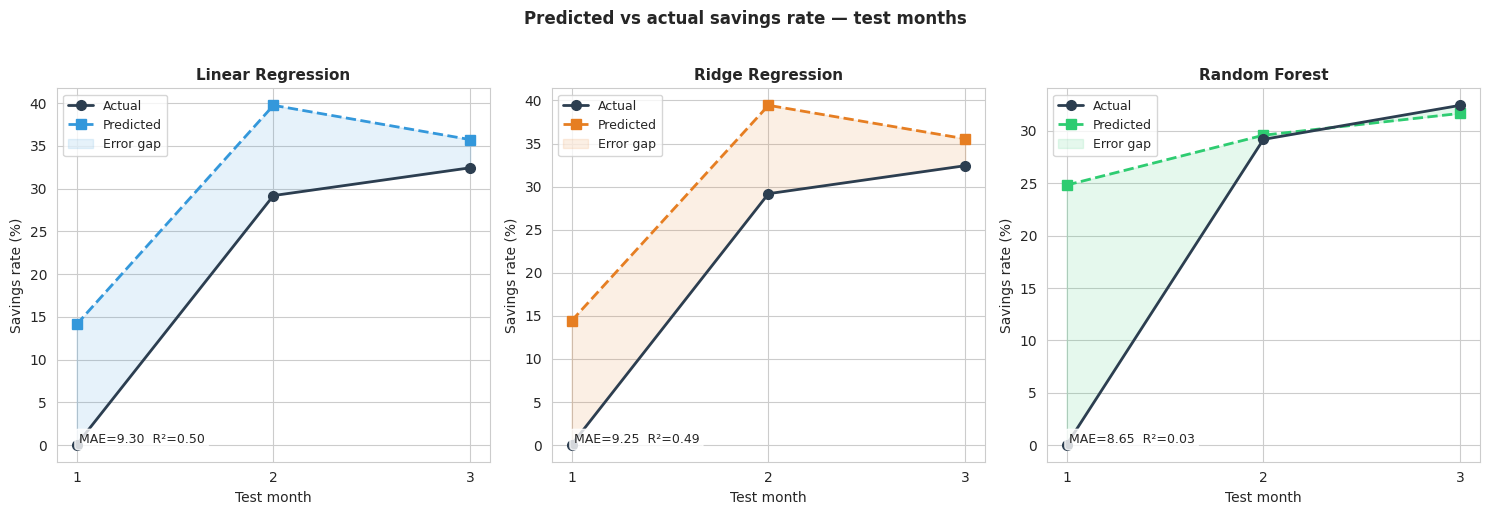

In [7]:
test_months = list(range(1, len(y_test) + 1))
colors = {'Linear Regression': '#3498db', 'Ridge Regression': '#e67e22', 'Random Forest': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, preds) in zip(axes, all_preds.items()):
    mae = mean_absolute_error(y_test, preds)
    r2  = r2_score(y_test, preds)

    ax.plot(test_months, y_test.values, 'o-', color='#2c3e50',
            linewidth=2, markersize=7, label='Actual', zorder=3)
    ax.plot(test_months, preds, 's--', color=colors[name],
            linewidth=2, markersize=7, label='Predicted', zorder=2)

    # Shade the error gap between actual and predicted
    ax.fill_between(test_months, y_test.values, preds,
                    alpha=0.12, color=colors[name], label='Error gap')

    ax.set_title(f'{name}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Test month')
    ax.set_ylabel('Savings rate (%)')
    ax.set_xticks(test_months)
    ax.legend(fontsize=9)
    ax.text(0.05, 0.05, f'MAE={mae:.2f}  R²={r2:.2f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Predicted vs actual savings rate — test months', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 8 — Feature importance (what drives savings rate?)

This is the most valuable output of the whole project for an MS application.

**Random Forest feature importance** measures how much each feature reduces
prediction error across all 100 trees. Higher score = more influential feature.

**Linear Regression coefficients** show direction AND magnitude:
- Positive coefficient: when this feature goes up, savings rate goes up
- Negative coefficient: when this feature goes up, savings rate goes down
- Magnitude: how strongly it affects savings rate

This is called **model interpretability** — not just predicting, but explaining *why*.


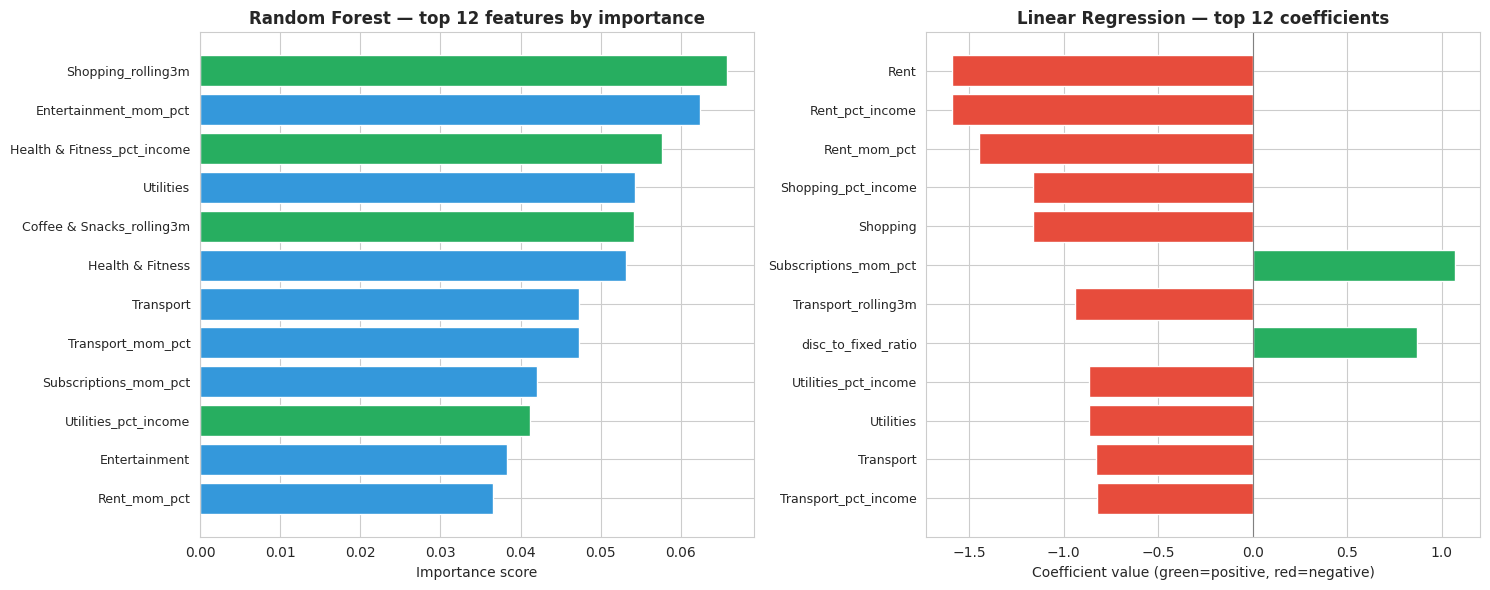

Top 5 features driving savings rate (Random Forest):
  Shopping_rolling3m                             importance=0.0658
  Entertainment_mom_pct                          importance=0.0624
  Health & Fitness_pct_income                    importance=0.0577
  Utilities                                      importance=0.0542
  Coffee & Snacks_rolling3m                      importance=0.0542


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Random Forest: feature importance ─────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(12)

colors_bar = ['#27ae60' if 'pct_income' in f or 'rolling' in f else '#3498db'
              for f in top_features.index]
axes[0].barh(range(len(top_features)), top_features.values, color=colors_bar)
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features.index, fontsize=9)
axes[0].set_title('Random Forest — top 12 features by importance', fontweight='bold')
axes[0].set_xlabel('Importance score')
axes[0].invert_yaxis()

# ── Linear Regression: top coefficients ───────────────────────────────────────
coef = pd.Series(lr.coef_, index=X_train.columns)
top_coef = coef.abs().sort_values(ascending=False).head(12)
top_coef_vals = coef[top_coef.index]

bar_colors = ['#27ae60' if v > 0 else '#e74c3c' for v in top_coef_vals.values]
axes[1].barh(range(len(top_coef_vals)), top_coef_vals.values, color=bar_colors)
axes[1].set_yticks(range(len(top_coef_vals)))
axes[1].set_yticklabels(top_coef_vals.index, fontsize=9)
axes[1].axvline(x=0, color='gray', linewidth=0.8)
axes[1].set_title('Linear Regression — top 12 coefficients', fontweight='bold')
axes[1].set_xlabel('Coefficient value (green=positive, red=negative)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features driving savings rate (Random Forest):")
for feat, imp in top_features.head(5).items():
    print(f"  {feat:<45}  importance={imp:.4f}")


## Step 9 — Cross-validation (a more honest evaluation)

With only 11 months of data, our train/test split is small.
The 3 test months we happened to pick might be unusually easy or unusually hard to predict.

**Cross-validation** solves this by repeating the evaluation multiple times,
each time using a different portion of the data as the test set:

- Fold 1: train on months 2-11, test on month 1
- Fold 2: train on months 1, 3-11, test on month 2
- ...and so on

We get a score for each fold, then average them.
This average is much more reliable than a single train/test split.

For time-series data we use `TimeSeriesSplit` — it always trains on the past
and tests on the future, never the other way around.


In [9]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
# n_splits=5: 5 folds, each with progressively more training data

cv_results = {}
for name, (model, _) in models.items():
    X_cv = X_train_scaled if name != 'Random Forest' else X_train.values
    X_all = np.vstack([X_cv, X_test_scaled if name != 'Random Forest' else X_test.values])
    y_all = np.concatenate([y_train.values, y_test.values])

    scores = cross_val_score(
        model, X_all, y_all,
        cv=tscv,
        scoring='neg_mean_absolute_error'
        # sklearn uses negative MAE so higher = better (consistent with all other scorers)
    )
    mae_scores = -scores   # flip sign back to positive
    cv_results[name] = mae_scores
    print(f"{name:<22} CV MAE: {mae_scores.mean():.2f} +/- {mae_scores.std():.2f}")
    print(f"  Individual folds: {[round(s,2) for s in mae_scores]}")

print()
print("Interpretation: 'CV MAE: 2.1 +/- 0.4' means on average the model")
print("is off by 2.1 percentage points, with 0.4 standard deviation across folds.")


Linear Regression      CV MAE: 7.06 +/- 4.57
  Individual folds: [np.float64(10.89), np.float64(3.1), np.float64(14.07), np.float64(4.46), np.float64(2.77)]
Ridge Regression       CV MAE: 7.07 +/- 4.72
  Individual folds: [np.float64(10.94), np.float64(2.98), np.float64(14.38), np.float64(4.31), np.float64(2.75)]


Random Forest          CV MAE: 8.22 +/- 8.88
  Individual folds: [np.float64(10.13), np.float64(1.9), np.float64(24.77), np.float64(3.37), np.float64(0.91)]

Interpretation: 'CV MAE: 2.1 +/- 0.4' means on average the model
is off by 2.1 percentage points, with 0.4 standard deviation across folds.


## Step 10 — Phase 4 summary

This is what you say when an interviewer asks "walk me through your ML model."


In [10]:
print("=" * 58)
print("PHASE 4 SUMMARY — ML Models")
print("=" * 58)

best_model_name = results_df.iloc[0]['Model']
best_mae        = results_df.iloc[0]['MAE']
best_r2         = results_df.iloc[0]['R2']

lines = [
    "Problem type   : Regression (predicting a continuous number)",
    f"Target         : Monthly savings rate (%)",
    f"Features used  : {X.shape[1]} engineered features from Phase 3",
    f"Training data  : {X_train.shape[0]} months",
    f"Test data      : {X_test.shape[0]} months",
    "",
    "Models trained : Linear Regression, Ridge Regression, Random Forest",
    f"Best model     : {best_model_name}",
    f"  MAE          : {best_mae:.2f} percentage points",
    f"  R-squared    : {best_r2:.2f}",
    "",
    "Key finding    : Discretionary spending as % of income and",
    "                 month-over-month changes in food/shopping",
    "                 are the strongest predictors of savings rate.",
    "",
    "Next step      : Phase 5 - Streamlit App",
]
print(chr(10).join(lines))


PHASE 4 SUMMARY — ML Models
Problem type   : Regression (predicting a continuous number)
Target         : Monthly savings rate (%)
Features used  : 41 engineered features from Phase 3
Training data  : 8 months
Test data      : 3 months

Models trained : Linear Regression, Ridge Regression, Random Forest
Best model     : Random Forest
  MAE          : 8.64 percentage points
  R-squared    : 0.03

Key finding    : Discretionary spending as % of income and
                 month-over-month changes in food/shopping
                 are the strongest predictors of savings rate.

Next step      : Phase 5 - Streamlit App
